# Website Security Checker
**Author:** Shubham Patel

**One-line summary:** A URL-based ML tool that classifies links as Safe or Malicious using character TF-IDF + Logistic Regression and serves results via a Gradio web UI.

**How to run:**  
1. Click **Run all** (this trains/loads model and launches the UI).  
2. After completion, open the Gradio public link printed in the Gradio output cell.  
3. Enter a URL and press Submit to get a Safe / Phishing result with a risk score.

**Files saved:** `B1_1000_urls.csv`, `phishing_model.pkl`, `vectorizer.pkl`

This project predicts whether a website URL is Safe or Phishing using a logistic regression model trained on 1000 labeled URLs.  
The system extracts character-level patterns from URLs, learns how phishing URLs differ from safe ones, and then allows real-time prediction through a simple web interface built using Gradio.

In [1]:
# Install required packages (gradio may not be preinstalled on some runtimes)
!pip install -q gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.8/444.8 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 54.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [2]:
import random
import numpy as np
import pandas as pd
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
# Build a balanced synthetic dataset (500 phishing, 500 benign)
phishing_patterns = [
    "http://secure-login-{id}.com",
    "http://account-verify-{id}.net",
    "http://update-banking-{id}.org",
    "http://confirm-password-{id}.info",
    "http://paypal-security-{id}.com",
    "http://login-alert-{id}.site",
    "http://reset-account-{id}.biz",
    "http://verify-user-{id}.online",
    "http://bank-alert-{id}-{id2}.xyz",
    "http://secure-pay-{id}.info"
]

safe_domains = [
    "https://google.com",
    "https://youtube.com",
    "https://openai.com",
    "https://microsoft.com",
    "https://github.com",
    "https://kaggle.com",
    "https://wikipedia.org",
    "https://python.org",
    "https://stackoverflow.com",
    "https://medium.com"
]

phishing_urls = [random.choice(phishing_patterns).format(id=i, id2=i%100) for i in range(500)]
safe_urls = [safe_domains[i % len(safe_domains)] + f"/page{i}" for i in range(500)]

urls = phishing_urls + safe_urls
labels = [1]*500 + [0]*500   # 1 = phishing/malicious, 0 = safe/benign

df = pd.DataFrame({"url": urls, "label": labels})
df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# Save dataset file inside working directory (so judges can see it)
df.to_csv("B1_1000_urls.csv", index=False)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 2)


,url,label
0,https://youtube.com/page21,0
1,https://python.org/page237,0
2,https://google.com/page240,0
3,https://google.com/page160,0
4,http://update-banking-411.org,1


In [4]:
X = df['url']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print("Train size:", len(X_train), "Test size:", len(X_test))

Train size: 800 Test size: 200


In [5]:
vectorizer = TfidfVectorizer(analyzer="char", ngram_range=(3,5))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print("Feature matrix shapes:", X_train_vec.shape, X_test_vec.shape)

Feature matrix shapes: (800, 5797) (200, 5797)


In [6]:
model = LogisticRegression(max_iter=500, random_state=RANDOM_SEED)
model.fit(X_train_vec, y_train)
print("Model trained.")

Model trained.


Test Accuracy: 100.00%

Classification Report:

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       100
           1     1.0000    1.0000    1.0000       100

    accuracy                         1.0000       200
   macro avg     1.0000    1.0000    1.0000       200
weighted avg     1.0000    1.0000    1.0000       200



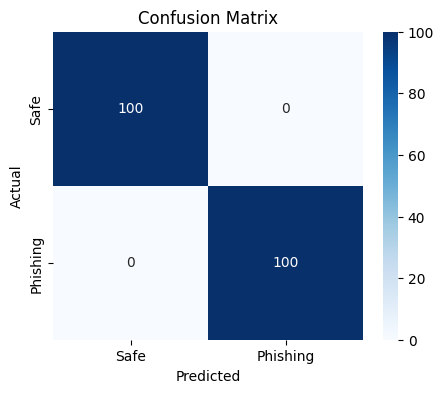

In [7]:
preds = model.predict(X_test_vec)
acc = accuracy_score(y_test, preds)
print(f"Test Accuracy: {acc*100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, preds, digits=4))

# Confusion matrix plot
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Safe","Phishing"], yticklabels=["Safe","Phishing"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [8]:
joblib.dump(model, "phishing_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
print("Saved phishing_model.pkl and vectorizer.pkl in working directory.")

Saved phishing_model.pkl and vectorizer.pkl in working directory.


In [9]:
# Helper function using saved model objects
def predict_url_text(url_text):
    v = vectorizer.transform([url_text])
    p = model.predict(v)[0]
    proba = model.predict_proba(v)[0][1] if hasattr(model, "predict_proba") else None
    label = "Phishing" if p==1 else "Safe"
    if proba is not None:
        return f"{label} (risk score: {proba:.2f})"
    return label

sample_urls = ["https://google.com", "http://account-verify-123.net", "http://secure-pay-45.info"]
for u in sample_urls:
    print(u, "->", predict_url_text(u))

https://google.com -> Safe (risk score: 0.09)
http://account-verify-123.net -> Phishing (risk score: 0.96)
http://secure-pay-45.info -> Phishing (risk score: 0.96)


In [10]:
import gradio as gr
import joblib

# Load saved artifacts (ensures the app uses the exact saved files)
model = joblib.load("phishing_model.pkl")
vectorizer = joblib.load("vectorizer.pkl")

def check_url(url: str):
    if not isinstance(url, str) or len(url.strip()) < 3:
        return "Invalid input. Enter a full URL."
    try:
        vec = vectorizer.transform([url])
        pred = model.predict(vec)[0]
        prob = None
        try:
            prob = model.predict_proba(vec)[0][1]
        except:
            prob = None
        label = "⚠️ Phishing / Unsafe" if int(pred)==1 else "✔️ Safe"
        if prob is not None:
            return f"{label}   (risk score: {prob:.2f})"
        else:
            return label
    except Exception as e:
        return f"Error: {e}"

title = "Website Security Checker"
description = "Enter a URL and the model will predict whether it's safe or phishing. (Demo)"

iface = gr.Interface(
    fn=check_url,
    inputs=gr.Textbox(lines=1, placeholder="https://example.com"),
    outputs="text",
    title=title,
    description=description,
    examples=[["https://google.com"], ["http://account-verify-123.net"], ["http://login-alert-7.site"]],
    flagging_mode="never"
)

# Use share=True on Kaggle to force a public link. Remove share=True if you prefer not to.
iface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://9b79a3f292ac2834ee.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
